## Exploratory Data Analysis for Climate Trends in Ethiopia 

Importing dependencies

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Data Loading and Date Parsing

**Loading the data and viewing the top rows of the data** 

In [2]:
df = pd.read_csv("ethiopia.csv")
print(df.shape)
print(df.head())
print(df.info())

(4108, 12)
   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  11.73    22.75     3.44      19.31          0.0  41.79  2.73   
1  2015    2  12.30    24.01     4.09      19.92          0.0  33.29  2.39   
2  2015    3  12.49    24.17     3.97      20.20          0.0  33.83  1.77   
3  2015    4  14.08    23.78     6.90      16.88          0.0  38.84  0.87   
4  2015    5  14.06    23.15     7.32      15.83          0.0  47.07  1.34   

   WS2M_MAX     PS  QV2M  
0      5.07  77.13  4.00  
1      4.19  77.14  3.35  
2      2.76  77.11  3.43  
3      1.28  77.07  4.60  
4      2.14  77.01  5.58  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-null   float64

In [3]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64
4107,2026,90,18.25,26.36,12.14,14.22,0.40,63.95,2.18,3.64,76.47,10.14


**adding country column**

In [4]:
df["country"] = "Ethiopia"

**Converting YEAR and DOY columns in to datetime column**

In [5]:
df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

**Extracting Month as a separate column**

In [6]:
df["Month"] = df["Date"].dt.month
df[["YEAR", "DOY", "Date", "Month"]].head()

,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


### 2. Summary Statistics & Missing-Value Report

**Replacing all occurrences of -999 with np.nan**

In [7]:
df.replace(-999, np.nan, inplace=True)

**Extracting and droping duplicated rows**

In [8]:
duplicates = df.duplicated().sum()
print(f"There are {duplicates} duplicate rows")

df = df.drop_duplicates()

There are 0 duplicate rows


**Checking duplicates for columns**

In [9]:
for col in df.columns:
    dup_count = df[col].duplicated().sum()
    print(f"{col}: {dup_count} duplicate values")

YEAR: 4096 duplicate values
DOY: 3742 duplicate values
T2M: 3247 duplicate values
T2M_MAX: 2994 duplicate values
T2M_MIN: 3076 duplicate values
T2M_RANGE: 2722 duplicate values
PRECTOTCORR: 2943 duplicate values
RH2M: 1316 duplicate values
WS2M: 3783 duplicate values
WS2M_MAX: 3577 duplicate values
PS: 4030 duplicate values
QV2M: 3212 duplicate values
country: 4107 duplicate values
Date: 0 duplicate values
Month: 4096 duplicate values


**Statistical summary** 

In [10]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


**Interpretation of Statistical summary**
**(YEAR, DOY, Date)**

- DOY ranges from 1 to 366, confirming full yearly coverage including leap years.

- The median date is 2020-08-15, indicating balanced distribution across years.
  
**Tempearture varibales** 

- It range from 10.03°C to 21.53°C with average daily temperature(T2M) 16.07°C.

- Maximumtemperature(T2M_MAX) is 30.93°C but Minimum  temperature(T2M_MIN) drops to 1.17°C, its shows seasonal fluctuations.

- Daily temperature range(T2M_RANGE) has a mean of 12.97°C, suggests a humid climate and its maximum 23.24°C suggest daily temperature variation.

**PRECTOTCORR/Precipitation** 

- The average daily rainfall is 3.63mm 
- The maximum value is 82.30mm is higher than the median(50%) 0.82mm, this indicates heavy rainfall. 

**Relative humidity/ RH2M** 

- The average humidity 68.41%, ranging from 14.42% to 91.93%.
- The median (71.12%) is slightly higher than the mean.
- Humidity is generally high, but occasional dry conditions exist, Slight skewness is observed.
  
**Wind Speed (WS2M, WS2M_MAX)**

- Average wind speed (WS2M) is 1.98 m/s, with a maximum of 4.13 m/s.
- Maximum wind (WS2M_MAX) reach 7.49 m/s.
- Wind speed is relatively stable, with occasional spikes indicating windy periods.

**Pressure (PS)**

- Atmospheric pressure is highly stable with a mean of 77.04 and very low variation (std ≈ 0.10), this suggests consistent atmospheric conditions across the dataset.

**Specific Humidity (QV2M)**

- Mean value is 9.70, ranging from 2.12 to 13.52.
- Moderate variability indicates changing moisture levels over time.



 **Counting missing values, Computing percentage of missing valuees, Listing values with >5%**

In [11]:
count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({
    "Missing Values" : count,
    "percentage (%)": missing_percent,
})

print(missing_report)
high_missing = missing_percent[missing_percent > 5]
if high_missing.empty:
    print("\nNo columns found with >5% missing values.")
else:
    print(f"{high_missing} number of  columns found with >5% missing values.")

             Missing Values  percentage (%)
YEAR                      0             0.0
DOY                       0             0.0
T2M                       0             0.0
T2M_MAX                   0             0.0
T2M_MIN                   0             0.0
T2M_RANGE                 0             0.0
PRECTOTCORR               0             0.0
RH2M                      0             0.0
WS2M                      0             0.0
WS2M_MAX                  0             0.0
PS                        0             0.0
QV2M                      0             0.0
country                   0             0.0
Date                      0             0.0
Month                     0             0.0

No columns found with >5% missing values.


**Missing Value Analysis**

The dataset shows no missing values across all columns and since no column is greater than 5%, no data cleaning required for missing values. It shows higher data quality and  suitable for exploratory data analysis. 

### 3. Outlier Detection & Basic Cleaning

In [12]:
#Selected columns to check for outliers
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

#Calculate Z-scores for each value in the columns
z_scores = stats.zscore(df[cols])

#Flag rows where |Z| > 3
outliers = (np.abs(z_scores) > 3)

#count rows 
outlier_count = outliers.any(axis=1).sum()

print(f"{outlier_count} rows contain outliers")

132 rows contain outliers


**Outlier Analysis**

- *Found*: 132 outliers

- *Observation*: Outliers rows are 132 and 132/4108 ~ 3 % outliers exist

- *Desision*: It should be retain

- *Reasoning*: The extreme values are expected and represent real-world weather conditions.

 **Handling remaining missing values**

In [13]:
row_missing_percent = df.isna().mean(axis=1) * 100
row_missing_percent.head()

df = df[row_missing_percent <= 30]

#applying forward-fill for weather variables

weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

df[weather_cols] = df[weather_cols].ffill()

#dropping rows 
df = df.dropna()

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


Rows with >30% missing data removed, variables forward-filled and remaining missing values were dropped


**Exporting cleaned dataset**

In [14]:
df.to_csv("data/ethiopia_clean.csv", index=False)

### 4.Time Series Analysis

C:\Users\user\AppData\Local\Temp\ipykernel_23288\2321122583.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df["T2M"].resample("M").mean()


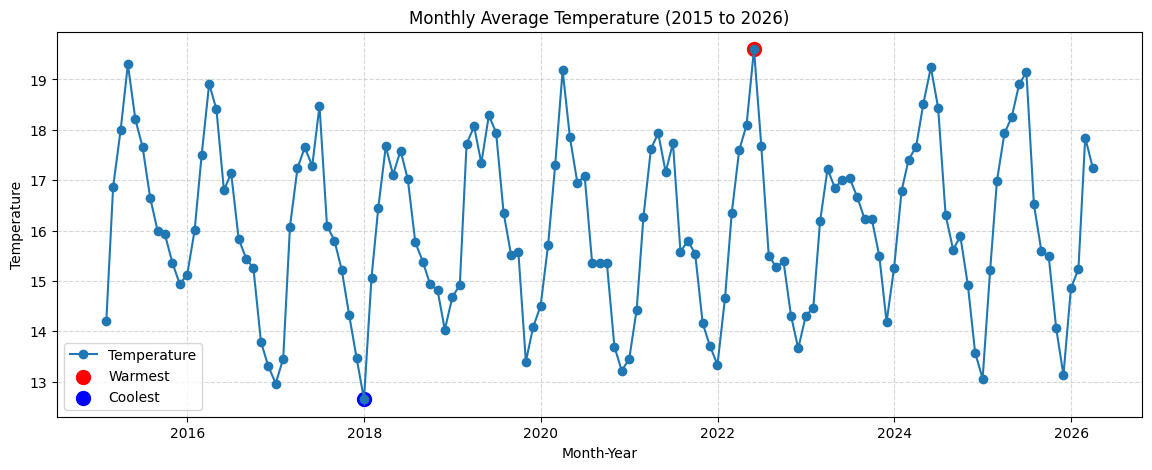

Warmest Month: 2022-05-31 00:00:00
Coolest Month: 2017-12-31 00:00:00


In [15]:
#Plotting monthly Average Temperature

# Convert DATE column to datetime
df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df.set_index("Date", inplace=True)

# Calculate monthly average temperature
monthly_temp = df["T2M"].resample("M").mean()

# Plotting monthly average Temperature
plt.figure(figsize=(14,5))

plt.plot(monthly_temp.index, monthly_temp.values, marker='o', label="Temperature")

# Find warmest and coolest months
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

warmest_value = monthly_temp.max()
coolest_value = monthly_temp.min()

# Highlight points
plt.scatter(warmest_month, warmest_value, color="red", s=100, label="Warmest")
plt.scatter(coolest_month, coolest_value, color="blue", s=100, label="Coolest") 

plt.title("Monthly Average Temperature (2015 to 2026)")
plt.xlabel("Month-Year")
plt.ylabel("Temperature")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

print("Warmest Month:", warmest_month)
print("Coolest Month:", coolest_month)


**Monthly Temperature Analysis**

Seasonality: it shows a clear repeating seasonal pattern, indicating consistent climate cycles over the years.

**Monthly total rainfall**

C:\Users\user\AppData\Local\Temp\ipykernel_23288\3705383339.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rain = df["PRECTOTCORR"].resample("M").sum()


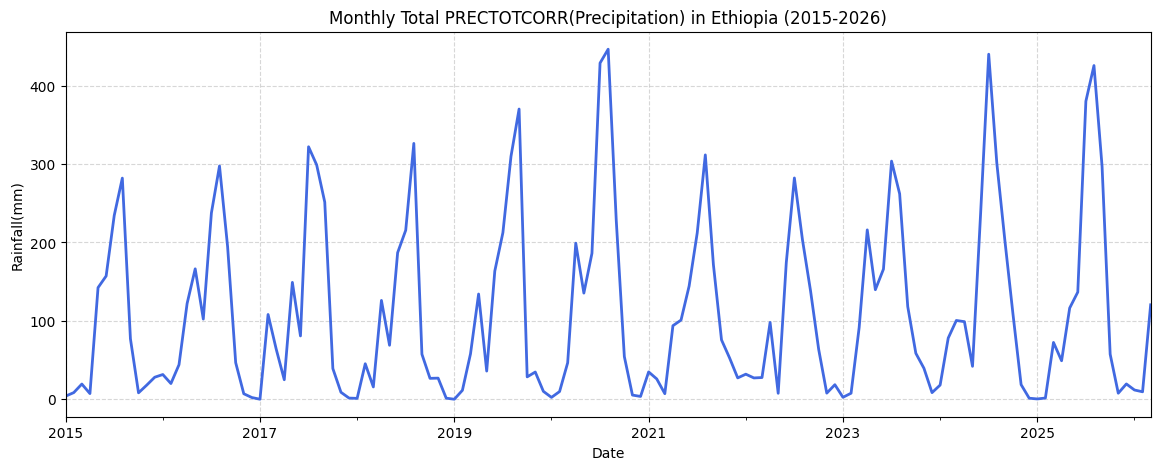

Rainy Months:
 Date
2020-08-31    446.65
2024-07-31    440.28
2020-07-31    429.02
Name: PRECTOTCORR, dtype: float64


In [16]:
#Plotting monthly Total Rainfall

# Convert DATE column to datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df.set_index("Date", inplace=True)

monthly_rain = df["PRECTOTCORR"].resample("M").sum()

plt.figure(figsize=(14,5))

monthly_rain.plot(color='royalblue', linewidth=2)

plt.title("Monthly Total PRECTOTCORR(Precipitation) in Ethiopia (2015-2026)")
plt.xlabel("Date")
plt.ylabel("Rainfall(mm)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#Identifying peak rainy months
top_rain = monthly_rain.sort_values(ascending=False).head(3)
print("Rainy Months:\n", top_rain)

### 5. Correlation and RelationShip Analysis

 Heatmap of correlations across all numeric columns


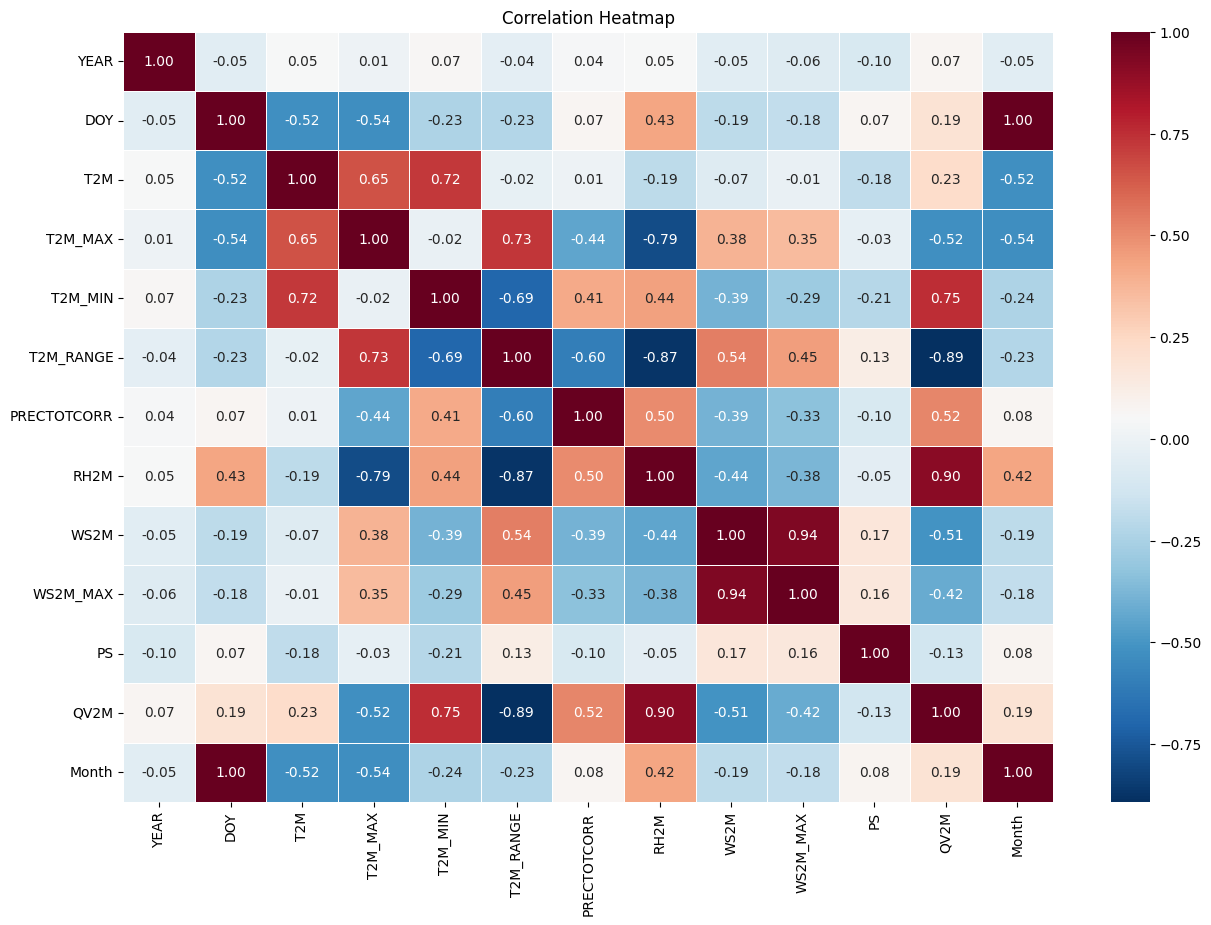

In [17]:
print(" Heatmap of correlations across all numeric columns")
#Select numeric columns
corr = df.select_dtypes(include="number").corr()

# Plotting a heatmap
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, fmt='.2f',  cmap='RdBu_r', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


**Correlation & Relationship Analysis**

- The Darker colors signify strong correlation, while light colors represents weaker correlations.

- Temperature and Humidity have positive correlation and move in same directions. As Temperature increases, humidity also increases. 

- Negative correlation variables move in opposite directions. An increase in one variable is associated with a decrease in the other.

**Scatter Plot 1: T2M vs RH2M**

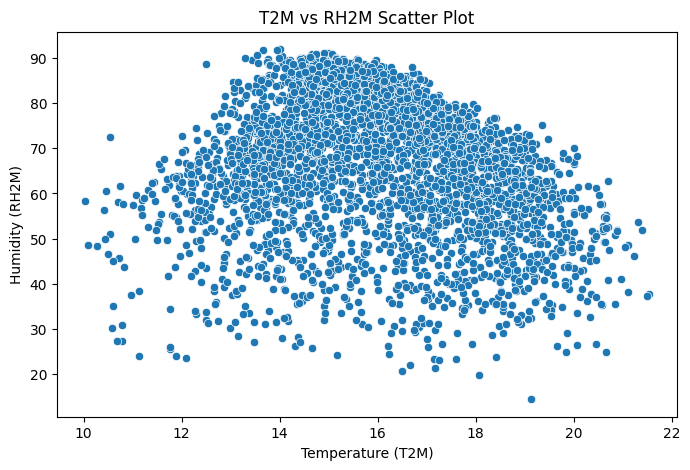

In [18]:
#Scatter plot between Temperature and Humidity
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["T2M"], y=df["RH2M"])

plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")

plt.title("T2M vs RH2M Scatter Plot")
plt.show()

**Scatter Plot 2: T2M_RANGE vs WS2M**

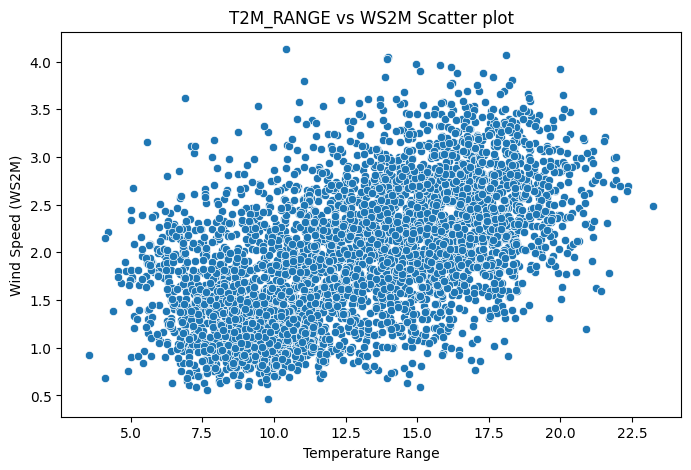

In [19]:
##Scatter plot between Temperature and Humidity

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["T2M_RANGE"], y=df["WS2M"])

plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")

plt.title("T2M_RANGE vs WS2M Scatter plot")
plt.show()

**The strongest correlations**

In [20]:
corr = df.select_dtypes(include="number").corr()

# Convert correlation matrix into pairs
corr_pairs = corr.unstack()

# Remove self-correlation (1.0)
corr_pairs = corr_pairs[corr_pairs != 1]

#remove duplicate pairs
corr_pairs = corr_pairs.drop_duplicates()

# Sort by strongest absolute correlation
strongest = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)


# Top 3 strongest correlations
print(strongest.head(3))

DOY   Month       0.996557
WS2M  WS2M_MAX    0.940826
RH2M  QV2M        0.904901
dtype: float64


**Strongest Correlations Analysis**

I.WS2M vs WS2M_MAX - 0.94

- Indicates when average wind speed increases, the maximum wind speed also increases proportionally.

II. RH2M vs QV2M - 0.90

- This shows that as atmospheric moisture content increases, relative humidity also increases.

III. T2M_RANGE vs QV2M, -0.89(strong negative correlation)

- This means that when temperature variation increases, atmospheric moisture tends to decrease. 
  
- This inverse relationship reflects typical weather behavior where drier conditions lead to larger temperature fluctuations. 


### 6. Distribution Analysis

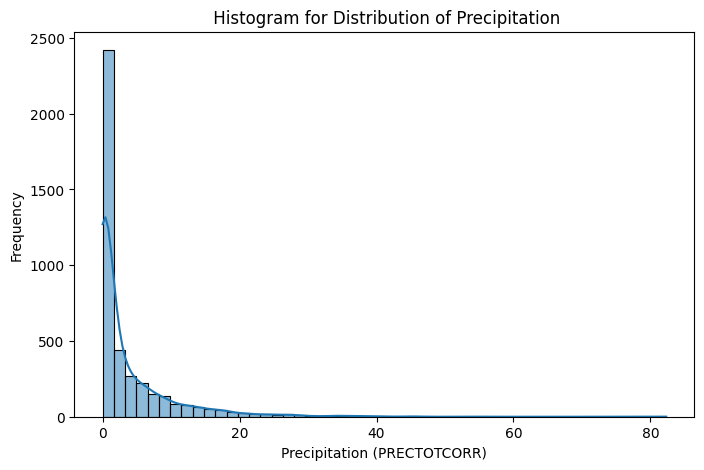

In [21]:
plt.figure(figsize=(8,5))

# Use log scale if data is highly skewed
sns.histplot(df["PRECTOTCORR"], bins=50, kde=True)

plt.xlabel("Precipitation (PRECTOTCORR)")
plt.ylabel("Frequency")
plt.title(" Histogram for Distribution of Precipitation")

plt.show()

**Precipitation Distribution**

- The distribution is highly right-skewed (positively skewed), most values are concentrated near 0 precipitation and a few extreme values extend up to around 80+, but they are rare. it shows Most days have little or no rainfall, heavy rainfall events are infrequent but extreme.

**Bubble Chart T2M vs RH2M, bubble size = PRECTOTCORR**

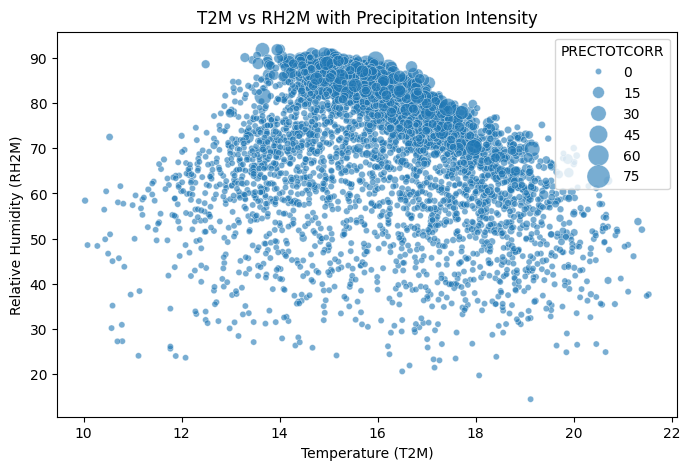

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="T2M",
    y="RH2M",
    size="PRECTOTCORR",
    sizes=(20, 300),
    alpha=0.6,
    legend=True
)

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("T2M vs RH2M with Precipitation Intensity")
plt.show()

**Observation**

- There is a clear negative relationship between temperature and humidity and Moderate temperature range (~14°C to 18°C), Higher humidity zones (~60%–90%)
Precipitation is influenced by a combination of moderate temperature and high humidity, rather than extreme values of either variable.